In [54]:
from pathlib import Path
import os
import itertools

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import scipy.optimize as opt

In [55]:
VOLUME_LOSS_PATH = Path(f"../preprocess/rawdata/processed/volume-loss/volume-loss.csv")
# Pixel size in mm
PIXEL_SIZE = 0.007406

POSITIVE_CUTOFF = 0.03

plt.rcParams.update({'font.size': 18})

def get_mask_path(data_type):
    return Path(f"../data/{data_type}/mask")

def get_target_path(data_type):
    return Path(f"../data/{data_type}/after/height")

class ImageDataset:
    def __init__(self, model=None, raw=False, return_mask=False):
        self.model = model
        self.image_list = []
        self.mask_list = []
        self.raw = raw
        self.return_mask = return_mask

    def load_raw_image(self, file_path):
        return np.load(file_path)

    def load_mask(self, mask_path):
        return np.load(mask_path)

    def load_image(self, file_path, mask_path):
        image = self.load_raw_image(file_path)
        mask = self.load_mask(mask_path)

        # Mask points where the profile is contamintated
        mask[image > POSITIVE_CUTOFF] = True

        if not self.raw:
            image[mask] = 0.0
        if self.return_mask:
            return -image, mask
        return -image

    def __iter__(self):
        # Yield each image and its corresponding mask (if return_mask is True) or raw image (if raw is True)
        for image_file, mask_file in zip(self.image_list, self.mask_list):
            yield self.load_image(image_file, mask_file)

class IdsImageDataset(ImageDataset):
    def __init__(self, image_ids, model=None, return_mask=False, raw=False):
        super().__init__(model=model, return_mask=return_mask, raw=raw)
        self.image_ids = image_ids
        data_types = ["train", "val", "test"]

        # Get the image directory based on whether a model is provided or not
        if model is not None:
            image_dirs = [get_save_path(model, dtype) / "numpy" for dtype in data_types]
        else:
            # If no model is provided, use the target path as the image directory
            image_dirs = [get_target_path(dtype) for dtype in data_types]

        mask_dirs = [get_mask_path(dtype) for dtype in data_types]

        self.image_list, self.mask_list = self._generate_file_lists(image_dirs, mask_dirs)

    def _generate_file_lists(self, image_dirs, mask_dirs):
        image_list = []
        mask_list = []
        for image_id in self.image_ids:
            # If file exists specific dir of image_dirs, add path of file and mask to list of files and masks
            for image_dir, mask_dir in zip(image_dirs, mask_dirs):
                image_file = image_dir / f"{image_id}.npy"
                mask_file = mask_dir / f"{image_id}.npy"
                if image_file.exists() and mask_file.exists():
                    image_list.append(image_file)
                    mask_list.append(mask_file)
                    break

        return image_list, mask_list

class DataTypeImageDataset(ImageDataset):
    def __init__(self, data_types, model=None, return_mask=False, raw=False):
        super().__init__(model=model, return_mask=return_mask, raw=raw)
        self.data_types = data_types

        self.image_list, self.mask_list = self._generate_file_lists()

    def _generate_file_lists(self):
        image_list = []
        mask_list = []
        for dtype in self.data_types:
            # Get the image directory based on whether a model is provided or not
            if self.model is not None:
                image_dir = get_save_path(self.model, dtype) / "numpy"
            else:
                # If no model is provided, use the target path as the image directory
                image_dir = get_target_path(dtype)

            mask_dir = get_mask_path(dtype)

            # Get the sorted list of files in the image directory
            file_list = os.listdir(image_dir)
            file_list.sort()

            image_list.extend([image_dir / file for file in file_list])
            mask_list.extend([mask_dir / file for file in file_list])
        return image_list, mask_list

def get_target_files(data_type):
    base_path = get_target_path(data_type)
    return [base_path / f for f in os.listdir(base_path)]

def get_mask_files(data_type):
    base_path = get_mask_path(data_type)
    return [base_path / f for f in os.listdir(base_path)]

def get_save_path(model, data_type):
    return Path(f"predictions/{model}-best/{data_type}")

def get_image(image_dir, mask_dir, file):
    return load_image(image_dir / file, mask_dir / file)

def load_raw_image(file_path):
    return np.load(file_path)

def load_mask(mask_path):
    return np.load(mask_path)

def load_image(file_path, mask_path, raw=False, return_mask=False):
    image = load_raw_image(file_path)
    mask = load_mask(mask_path)

    # Mask points where the profile is contamintated
    mask[image > POSITIVE_CUTOFF] = True


    if not raw:
        image[mask] = 0.0
    if return_mask:
        return -image, mask
    return -image

def get_id_image_generator(image_ids, model=None, return_mask=False, raw=False):
    data_types = ["train", "val", "test"]

    # Get the image directory based on whether a model is provided or not
    if model is not None:
        image_dirs = [get_save_path(model, dtype) / "numpy" for dtype in data_types]
    else:
        # If no model is provided, use the target path as the image directory
        image_dirs = [get_target_path(dtype) for dtype in data_types]

    mask_dirs = [get_mask_path(dtype) for dtype in data_types]

    image_list = []
    mask_list = []
    for image_id in image_ids:
        # If file exists specific dir of image_dirs, add path of file and mask to list of files and masks
        for image_dir, mask_dir in zip(image_dirs, mask_dirs):
            image_file = image_dir / f"{image_id}.npy"
            mask_file = mask_dir / f"{image_id}.npy"
            if image_file.exists() and mask_file.exists():
                image_list.append(image_file)
                mask_list.append(mask_file)
                break

    yield from get_image_generator(image_list, mask_list, raw=raw, return_mask=return_mask)

def get_datatype_image_generator(data_types, model=None, return_mask=False, raw=False):
    for dtype in data_types:
        # Get the image directory based on whether a model is provided or not
        if model is not None:
            image_dir = get_save_path(model, dtype) / "numpy"
        else:
            # If no model is provided, use the target path as the image directory
            image_dir = get_target_path(dtype)

        mask_dir = get_mask_path(dtype)

        # Get the sorted list of files in the image directory
        file_list = os.listdir(image_dir)
        file_list.sort()

        image_list = [image_dir / file for file in file_list]
        mask_list = [mask_dir / file for file in file_list]

    yield from get_image_generator(image_list, mask_list, return_mask=return_mask, raw=raw)

def get_image_generator(image_list, mask_list, return_mask=False, raw=False):
        # Yield each image and its corresponding mask (if return_mask is True) or raw image (if raw is True)
        for image_file, mask_file in zip(image_list, mask_list):
            yield load_image(image_file, mask_file, raw=raw, return_mask=return_mask)

def calc_lower_loss(image):
    """Sum all negative elements"""
    return image[image > 0.0].sum()

def calc_lower_max_loss(image):
    return image[image > 0.0].min()

def calc_loss(image):
    """Sum all negative elements"""
    return image.sum()

def calc_max_loss(image):
    return image.min()

def get_loss_df(image_path, mask_path):
    """Create a pandas df from the loss of all height profiles"""
    file_list = os.listdir(image_path)
    loss = []
    max_loss = []
    lower_loss = []
    lower_max_loss = []

    for file in file_list:
        image = get_image(image_path, mask_path, file)
        loss.append(calc_loss(image))
        max_loss.append(calc_max_loss(image))
        lower_loss.append(calc_lower_loss(image))
        lower_max_loss.append(calc_lower_max_loss(image))

    ident = [file.replace(".npy", "") for file in file_list]
    return pd.DataFrame({"id": ident, "loss": loss, "max_loss": max_loss, "lower_loss": lower_loss, "lower_max_loss": lower_max_loss})

def load_inibitor_map():
    result = pd.read_csv(VOLUME_LOSS_PATH, index_col=0)
    result["inhibitor"] = result.id.str[:-2]
    return result

def create_joined_df(model, data_types):

    # Read inhibitor map
    results = load_inibitor_map()
    # Create inhibitor id
    all_losses = []
    for dtype in data_types:
        numpy_save_path = get_save_path(model, dtype) / "numpy"
        ground_truth_path = get_target_path(dtype)
        mask_path = get_mask_path(dtype)

        # Calculate the corrision for target and prediciton and join the dataframes
        losses = get_loss_df(ground_truth_path, mask_path).join(get_loss_df(numpy_save_path, mask_path).set_index("id"), on="id", how="inner", lsuffix="_target", rsuffix="_predict")
        # losses = get_loss_df(numpy_save_path, mask_path).join(get_loss_df(numpy_save_path, mask_path).set_index("id"), on="id", how="inner", lsuffix="_target", rsuffix="_predict")

        # Add data type indentifier
        losses["type"] = dtype
        all_losses.append(losses)

    # Concat the two datatype dataframes
    losses = pd.concat(all_losses)

    # Join to the inhibitor map
    results = results.join(losses.set_index("id"), on="id", how="inner").sort_values("id")

    return results

def add_volume_loss(results):
    # Determine the volume loss
    results["volumeloss_target"] = results.loss_target * PIXEL_SIZE**2
    results["volumeloss_predict"] = results.loss_predict * PIXEL_SIZE**2
    results["lower_volumeloss_target"] = results.lower_loss_target * PIXEL_SIZE**2
    results["lower_volumeloss_predict"] = results.lower_loss_predict * PIXEL_SIZE**2

    return results

def add_inhibitor_loss(results):
    # Calculate loss per inhibitor
    inhibitor = results[["inhibitor", "type", "loss_target", "loss_predict", "lower_loss_target", "lower_loss_predict", "volumeloss_target", "volumeloss_predict",  "lower_volumeloss_target", "lower_volumeloss_predict"]].groupby(["inhibitor", "type"]).agg("mean").reset_index()
    return inhibitor

def create_result_df(model, data_types):
    results = create_joined_df(model, data_types)
    results = add_volume_loss(results)
    inhibitor = add_inhibitor_loss(results)
    return results, inhibitor

def create_corrected_result_df(model, data_types):
    # Linear regression to correct model
    data_types = ["train"]
    train_results = create_joined_df(model, data_types)
    train_results = add_volume_loss(train_results)

    def linear(t, b):
        return 1.0 * t + b

    popt, pcov = opt.curve_fit(linear, train_results.volumeloss_target, train_results.volumeloss_predict)
    popt, pcov

    # Linear regression to correct model
    data_types = ["train", "val", "test"]
    results = create_joined_df(model, data_types)
    results = add_volume_loss(results)

    results.volumeloss_predict = (results.volumeloss_predict - popt[0])

    inhibitor = add_inhibitor_loss(results)
    return results, inhibitor, popt

def rel_pred_loss(df):
    return df.volumeloss_predict / df.volumeloss_target.max()

def rel_pred_loss_lower(df):
    return df.lower_volumeloss_predict / df.lower_volumeloss_target.max()

def rel_target_loss(df):
    return df.volumeloss_target / df.volumeloss_target.max()

def rel_target_loss_lower(df):
    return df.lower_volumeloss_target / df.lower_volumeloss_target.max()

def difference(df):
    return (df.volumeloss_target - df.volumeloss_predict)/(np.max((df.volumeloss_target - df.volumeloss_predict)) - np.min((df.volumeloss_target - df.volumeloss_predict)))

def deviation_percent(df):
    return 100 * (df.volumeloss_target - df.volumeloss_predict) / df.volumeloss_target

# Determine the average NaCl volume loss

In [56]:
# Get loss df of all datatype
data_types = ["train", "val", "test"]
train_loss_df = [get_loss_df(get_target_path(dtype), get_mask_path(dtype)) for dtype in data_types]
train_loss_df = pd.concat(train_loss_df)

# Join with inhibitor map
inhibitor_df = load_inibitor_map()
inhibitor_df.rename(columns={"volumeloss": "ci_lower_volumeloss"}, inplace=True)
inhibitor_df = inhibitor_df.join(train_loss_df.set_index("id"), on="id", how="inner")

# Add addtional volume losses
inhibitor_df["lower_volumeloss"] = inhibitor_df.lower_loss * PIXEL_SIZE**2
inhibitor_df["max_lower_volumeloss"] = inhibitor_df.lower_max_loss * PIXEL_SIZE**2
inhibitor_df["volumeloss"] = inhibitor_df.loss * PIXEL_SIZE**2
inhibitor_df["max_volumeloss"] = inhibitor_df.max_loss * PIXEL_SIZE**2

nacl_df = inhibitor_df[inhibitor_df.name == "NaCl"]

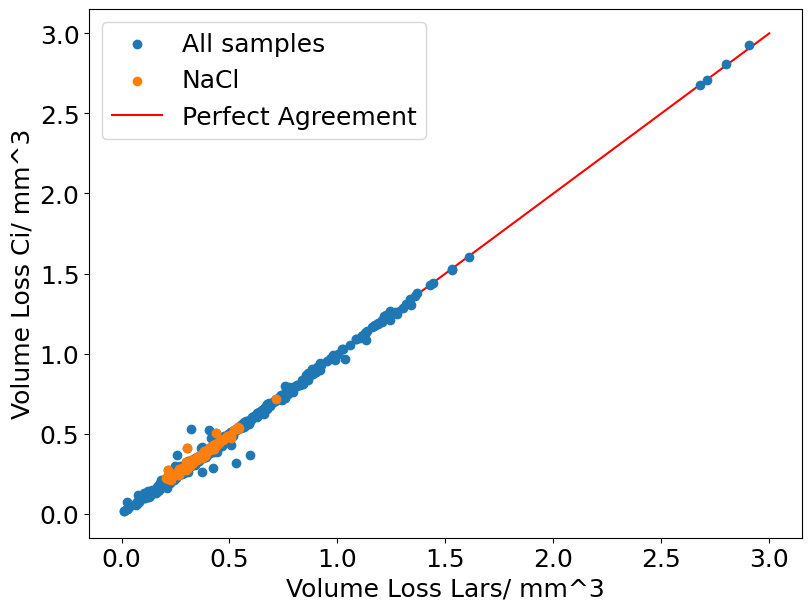

In [57]:
# Compare the volume loss determined by Ci and by me for all samples and the NaCl samples in particular
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.scatter(inhibitor_df.lower_volumeloss, inhibitor_df.ci_lower_volumeloss, label="All samples")
ax.scatter(nacl_df.lower_volumeloss, nacl_df.ci_lower_volumeloss, label="NaCl")
ax.plot([0, 3], [0, 3], color='red', label='Perfect Agreement', zorder=0)
ax.set_xlabel("Volume Loss Lars/ mm^3")
ax.set_ylabel("Volume Loss Ci/ mm^3")
ax.legend()

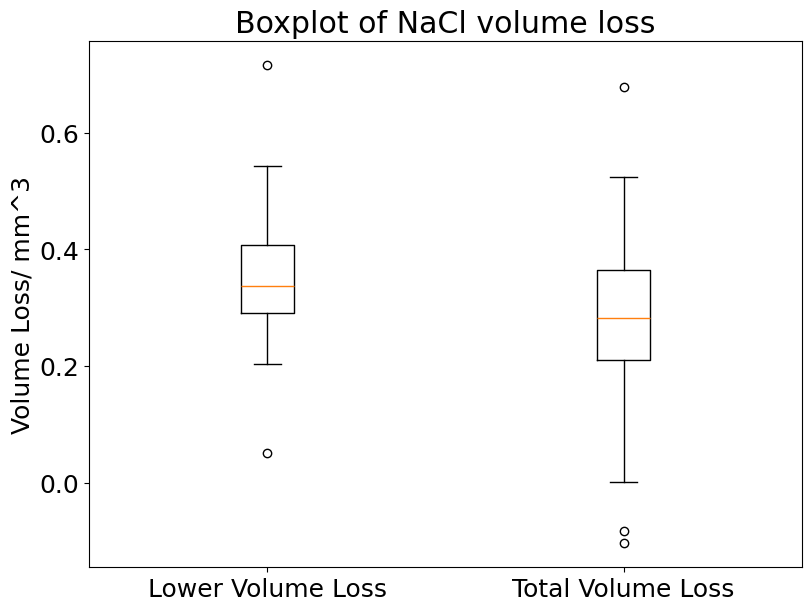

In [58]:
# Boxplot of NaCl sample volume loss and lower volume loss
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.boxplot([nacl_df.lower_volumeloss, nacl_df.volumeloss])
ax.set_ylabel("Volume Loss/ mm^3")
ax.set_title("Boxplot of NaCl volume loss")
ax.set_xticklabels(["Lower Volume Loss", "Total Volume Loss"])
plt.show()

There are two outliers present in the NaCl samples. Let's have a look at them and compare to the average NaCl sample.

In [59]:
# Calculate NaCl median
NACL_VOLUMELOSS = nacl_df.volumeloss.median()
NACL_LOWER_VOLUMELOSS = nacl_df.lower_volumeloss.median()
NACL_VOLUMELOSS, NACL_LOWER_VOLUMELOSS

(np.float64(0.28296072959270197), np.float64(0.3378012559940482))

# Investigate Corrision measurment methods

In [60]:
def get_min_max_loss(image_gen):
    """Determine min and max values of images in a generator"""
    total_max = -np.inf
    total_min = np.inf

    for image in image_gen:
        image_max = np.max(image)
        image_min = np.min(image)
        if image_max > total_max:
            total_max = image_max
        if image_min < total_min:
            total_min = image_min
    return total_min, total_max

### NaCl

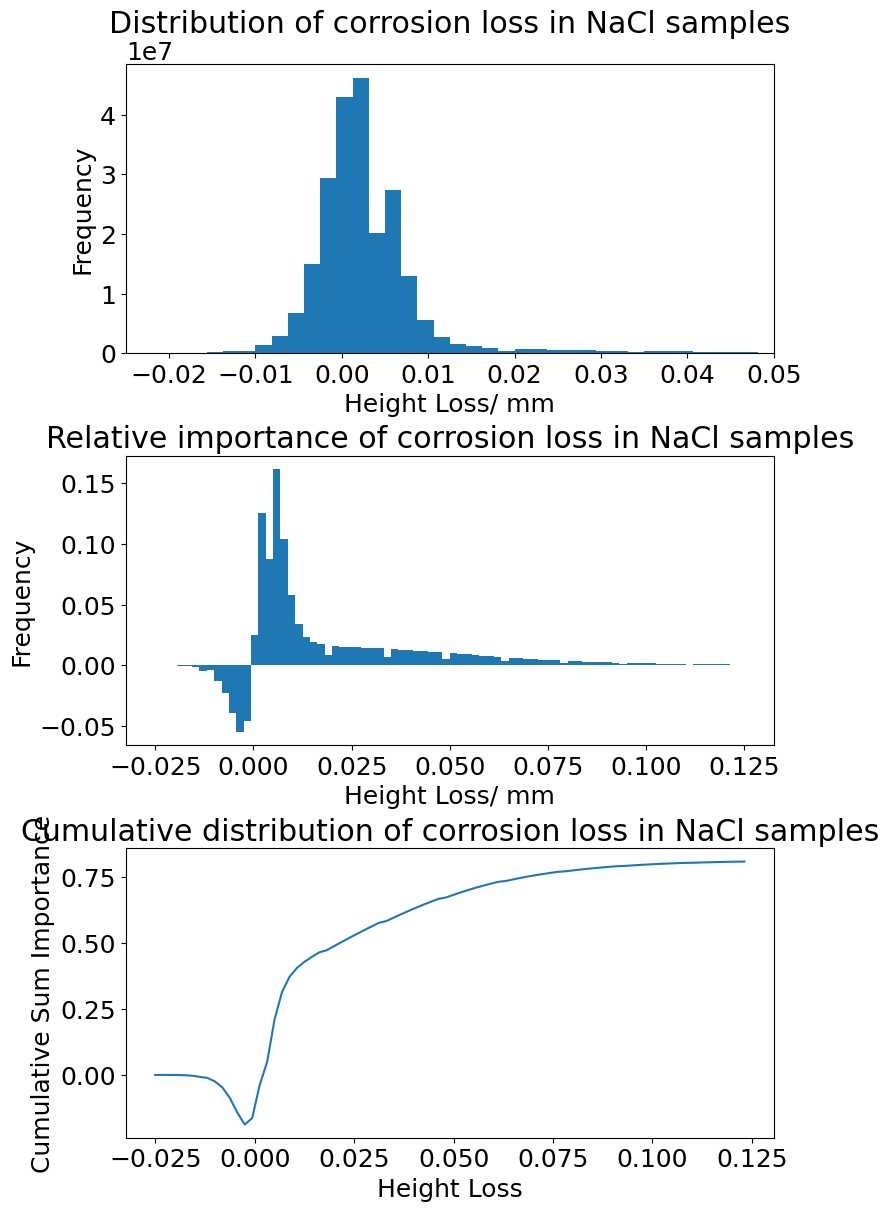

In [61]:

ground_truth_dir = get_target_path("train")
mask_dir = get_mask_path("train")

nacl_files = [ground_truth_dir / f"{id}.npy" for id in nacl_df.id]
nacl_masks = [mask_dir / f"{id}.npy" for id in nacl_df.id]
# Get the min and max val for NaCl samples
# min_val, max_val = get_min_max_loss([ground_truth_dir / f"{id}.npy" for id in nacl_df.id], [mask_dir / f"{id}.npy" for id in nacl_df.id])
min_val = -0.025
max_val = 0.125

# Get images for NaCl samples
values = []
for nacl_file, nacl_mask in zip(nacl_files, nacl_masks):
    image, mask = load_image(nacl_file, nacl_mask, return_mask=True)
    values.extend(image[~mask].ravel())
values = np.array(values)

# Show the unweighted and weighted distribution of values in the NaCl samples
fig, ax = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)
ax[0].hist(values, bins=80, range=(min_val, max_val))
ax[0].set_xlabel("Height Loss/ mm")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Distribution of corrosion loss in NaCl samples")
ax[0].set_xlim(min_val, 0.05)


hist, bins, _ = ax[1].hist(values, bins=80, range=(min_val, max_val), weights=values / values[values > 0].sum())
ax[1].set_xlabel("Height Loss/ mm")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Relative importance of corrosion loss in NaCl samples")

# Add cdf of the second plot
cdf = np.cumsum(hist)
ax[2].plot(bins[:-1], cdf, label="CDF")
ax[2].set_xlabel("Height Loss")
ax[2].set_ylabel("Cumulative Sum Importance")
ax[2].set_title("Cumulative distribution of corrosion loss in NaCl samples")

plt.show()

/tmp/ipykernel_421423/4196831133.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacl_df["volumeloss_diff"] = (nacl_df.volumeloss - nacl_df.volumeloss.median()).abs()
/tmp/ipykernel_421423/4196831133.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacl_df["lower_volumeloss_diff"] = (nacl_df.lower_volumeloss - nacl_df.lower_volumeloss.median()).abs()


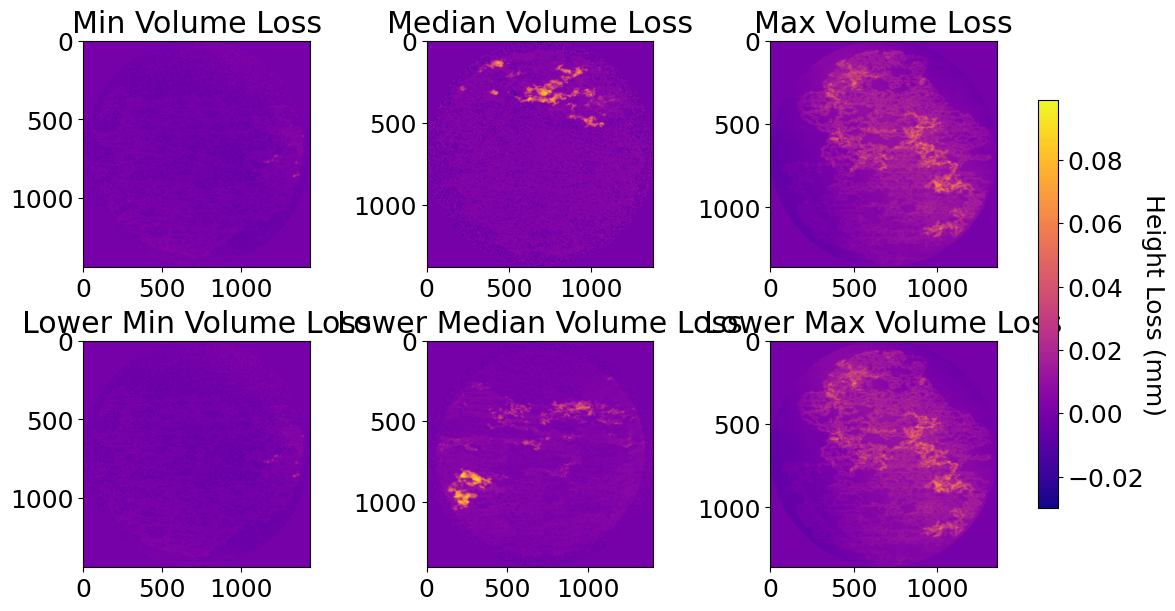

In [62]:
max_id = nacl_df[nacl_df.volumeloss == nacl_df.volumeloss.max()].id.values[0]
min_id = nacl_df[nacl_df.volumeloss == nacl_df.volumeloss.min()].id.values[0]
# Get id with volume loss closest to median
nacl_df["volumeloss_diff"] = (nacl_df.volumeloss - nacl_df.volumeloss.median()).abs()
avg_id = nacl_df[nacl_df.volumeloss_diff == nacl_df.volumeloss_diff.min()].id.values[0]

lower_max_id = nacl_df[nacl_df.lower_volumeloss == nacl_df.lower_volumeloss.max()].id.values[0]
lower_min_id = nacl_df[nacl_df.lower_volumeloss == nacl_df.lower_volumeloss.min()].id.values[0]
# Get id with volume loss closest to median
nacl_df["lower_volumeloss_diff"] = (nacl_df.lower_volumeloss - nacl_df.lower_volumeloss.median()).abs()
lower_avg_id = nacl_df[nacl_df.lower_volumeloss_diff == nacl_df.lower_volumeloss_diff.min()].id.values[0]

min_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{min_id}.npy")
max_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{max_id}.npy")
avg_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{avg_id}.npy")

lower_min_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{lower_min_id}.npy")
lower_max_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{lower_max_id}.npy")
lower_avg_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{lower_avg_id}.npy")


vmin = min(min_image.min(), max_image.min(), avg_image.min(), lower_min_image.min(), lower_max_image.min(), lower_avg_image.min())
# vmin = min(lower_min_image.min(), lower_max_image.min(), lower_avg_image.min())
vmax = max(min_image.max(), max_image.max(), avg_image.max(), lower_min_image.max(), lower_max_image.max(), lower_avg_image.max())

# Show min and max and average image side by side
fig, ax = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
ax[0][0].imshow(min_image, vmin=vmin, vmax=vmax, cmap="plasma")
ax[0][0].set_title("Min Volume Loss")
ax[0][1].imshow(avg_image, vmin=vmin, vmax=vmax, cmap="plasma")
ax[0][1].set_title("Median Volume Loss")
ax[0][2].imshow(max_image, vmin=vmin, vmax=vmax, cmap="plasma")
ax[0][2].set_title("Max Volume Loss")

ax[1][0].imshow(lower_min_image, vmin=vmin, vmax=vmax, cmap="plasma")
ax[1][0].set_title("Lower Min Volume Loss")
ax[1][1].imshow(lower_avg_image, vmin=vmin, vmax=vmax, cmap="plasma")
ax[1][1].set_title("Lower Median Volume Loss")
ax[1][2].imshow(lower_max_image, vmin=vmin, vmax=vmax, cmap="plasma")
ax[1][2].set_title("Lower Max Volume Loss")

# Add colorbar for with scaling for all three images
cbar = fig.colorbar(ax[0][0].images[0], ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Height Loss (mm)', rotation=270, labelpad=15)
plt.show()

### All samples

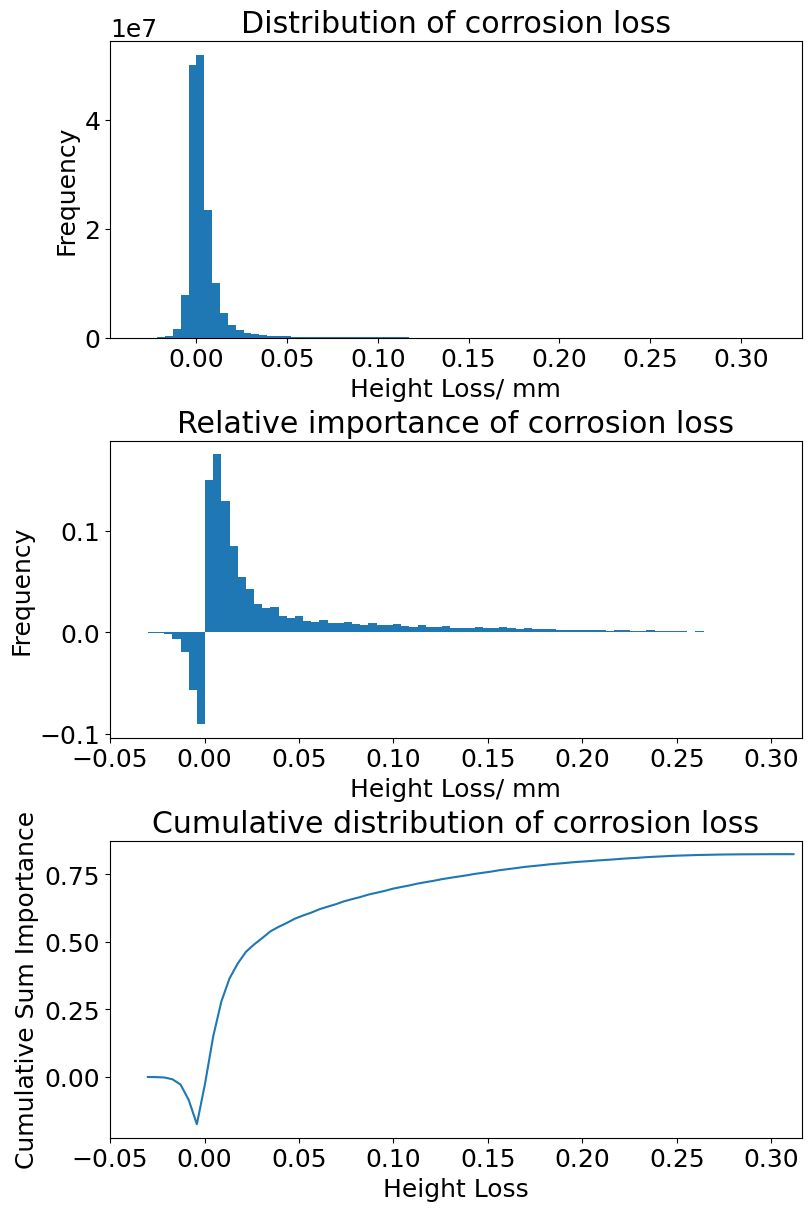

In [63]:
# Get the min and max val for NaCl samples
min_val, max_val = get_min_max_loss(get_datatype_image_generator(["train", "val", "test"]))

values = np.concatenate([image[~mask].ravel() for image, mask in get_datatype_image_generator(["train", "val", "test"], return_mask=True)])

# Show the unweighted and weighted distribution of values
fig, ax = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)
ax[0].hist(values, bins=80, range=(min_val, max_val))
ax[0].set_xlabel("Height Loss/ mm")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Distribution of corrosion loss")
# ax[0].set_xlim(-0.05, 0.1)

hist, bins, _ = ax[1].hist(values, bins=80, range=(min_val, max_val), weights=values / values[values > 0].sum())
ax[1].set_xlabel("Height Loss/ mm")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Relative importance of corrosion loss")
ax[1].set_xlim(-0.05, max_val)

# Add cdf of the second plot
cdf = np.cumsum(hist)
ax[2].plot(bins[:-1], cdf, label="CDF")
ax[2].set_xlabel("Height Loss")
ax[2].set_ylabel("Cumulative Sum Importance")
ax[2].set_title("Cumulative distribution of corrosion loss")
ax[2].set_xlim(-0.05, max_val)

plt.show()

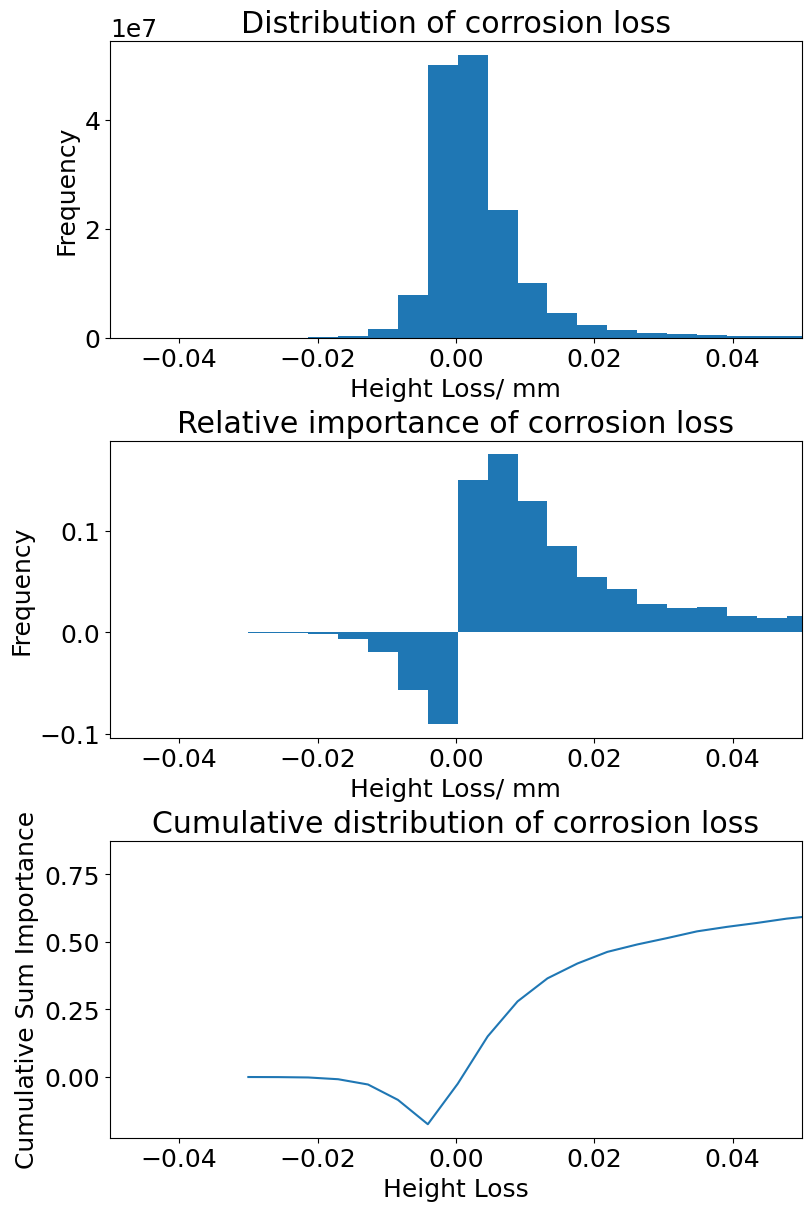

In [64]:
# Show the unweighted and weighted distribution of values
fig, ax = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)
ax[0].hist(values, bins=80, range=(min_val, max_val))
ax[0].set_xlabel("Height Loss/ mm")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Distribution of corrosion loss")
ax[0].set_xlim(-0.05, 0.05)

hist, bins, _ = ax[1].hist(values, bins=80, range=(min_val, max_val), weights=values / values[values > 0].sum())
ax[1].set_xlabel("Height Loss/ mm")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Relative importance of corrosion loss")
ax[1].set_xlim(-0.05, 0.05)

# Add cdf of the second plot
cdf = np.cumsum(hist)
ax[2].plot(bins[:-1], cdf, label="CDF")
ax[2].set_xlabel("Height Loss")
ax[2].set_ylabel("Cumulative Sum Importance")
ax[2].set_title("Cumulative distribution of corrosion loss")
ax[2].set_xlim(-0.05, 0.05)

plt.show()


In [65]:
def calc_ie_symmetric(loss):
    difference = NACL_VOLUMELOSS - loss

    if difference >= 0.0:
        return difference / NACL_VOLUMELOSS * 100
    else:
        return difference / loss * 100

def calc_ie_symmetric_lower(loss):
    difference = NACL_LOWER_VOLUMELOSS - loss

    if difference >= 0.0:
        return difference / NACL_LOWER_VOLUMELOSS * 100
    else:
        return difference / loss * 100


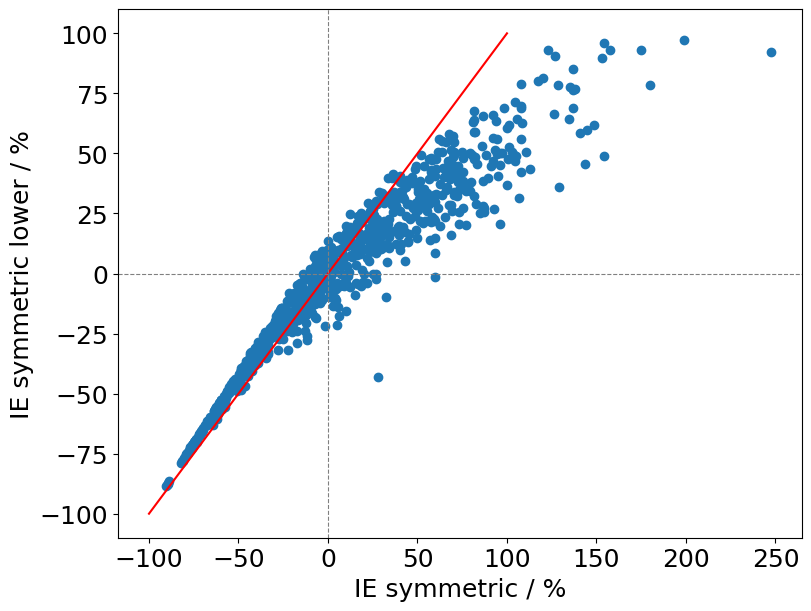

In [66]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
# Apply function to every entry in dataframe
x = inhibitor_df.volumeloss.apply(calc_ie_symmetric)
y = inhibitor_df.lower_volumeloss.apply(calc_ie_symmetric_lower)
ax.scatter(x, y)

ax.plot(np.arange(-100, 110, 10), np.arange(-100, 110, 10), color="r")
ax.set_xlabel("IE symmetric / %")
ax.set_ylabel("IE symmetric lower / %")
# ax.set_xticks(np.arange(-100, 110, 20))
# ax.set_yticks(np.arange(-100, 110, 20))
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)


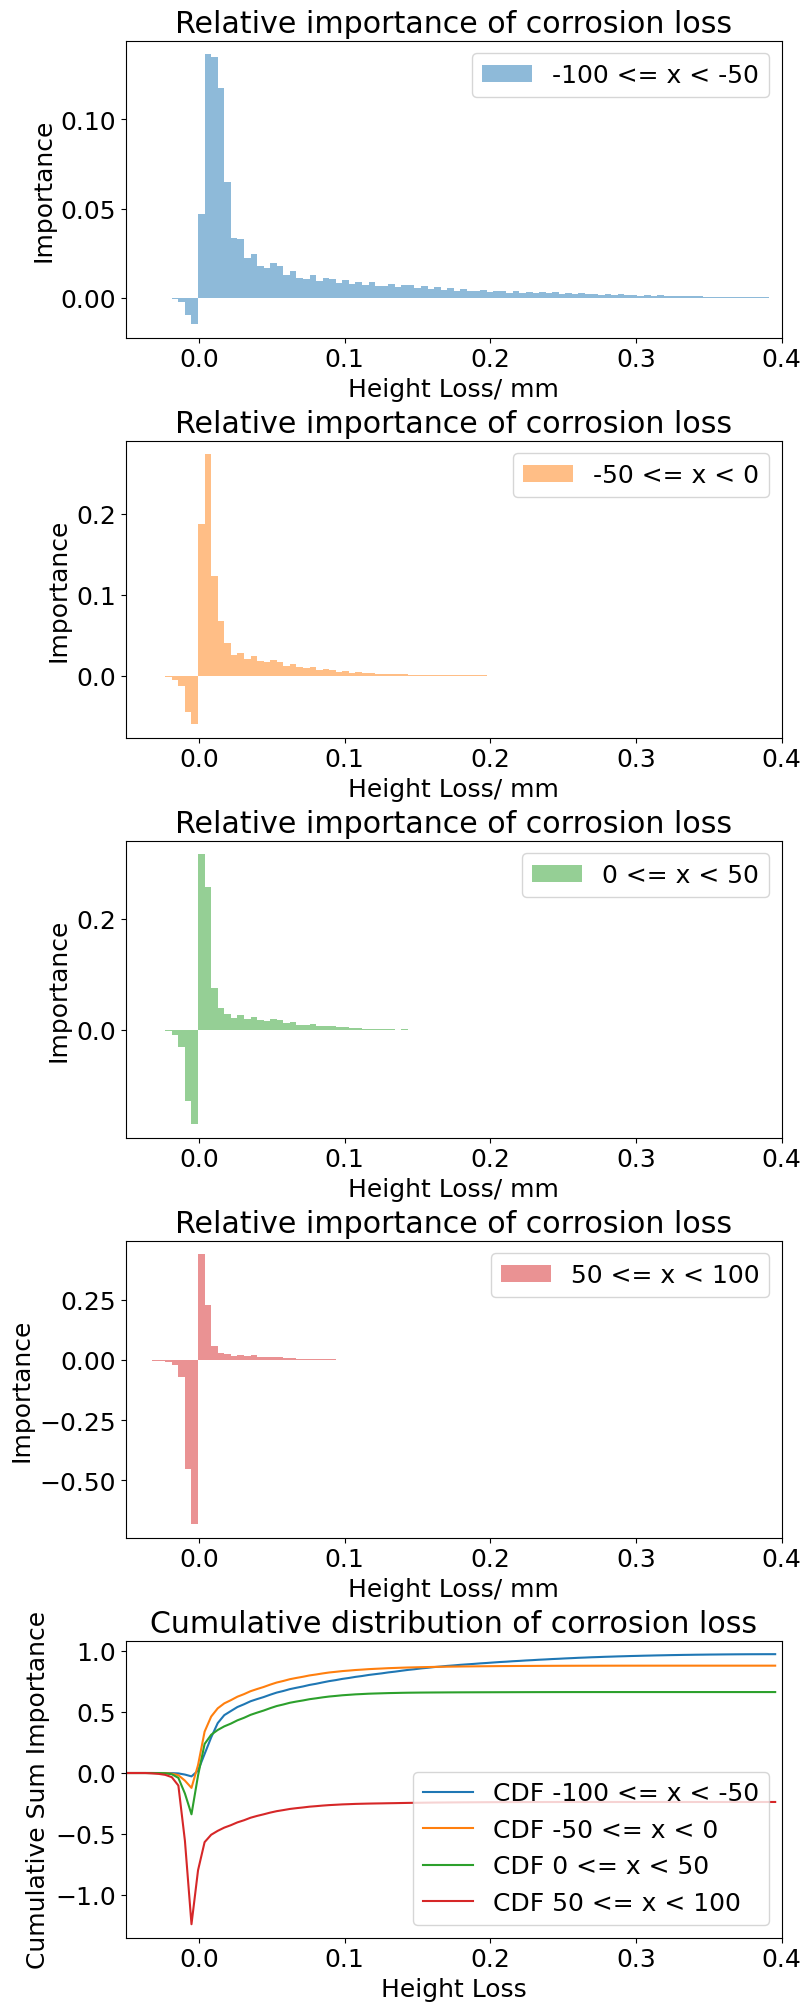

In [67]:
# Weighted histogram of categorized by IE symmetric lower
inhibitor_df["ie_symmetric_lower"] = inhibitor_df.lower_volumeloss.apply(calc_ie_symmetric_lower)
ie_range = np.arange(-100, 101, 50)
ranges = zip(ie_range[:-1], ie_range[1:])
fig, ax = plt.subplots(len(ie_range), 1, figsize=(8, (len(ie_range))*4), constrained_layout=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = itertools.cycle(colors)

i = 0
for x_min, x_max in ranges:
    subset = inhibitor_df[(inhibitor_df.ie_symmetric_lower >= x_min) & (inhibitor_df.ie_symmetric_lower < x_max)]
    image_dataset = IdsImageDataset(subset.id.values, return_mask=True)
    # Get images
    values = []
    for image, mask in image_dataset:
        values.extend(image[~mask].ravel())
    values = np.array(values)

    # # Get the min and max val for NaCl samples
    # min_val, max_val = np.min(values), np.max(values)

    # hist, bins, _ = ax[0].hist(values, bins=100, range=(min_val, max_val), weights=values / values[values > 0].sum(), alpha=0.5, label=f"{x_min} <= x < {x_max}")
    hist, bins, _ = ax[i].hist(values, bins=100, range=(-0.05, 0.4), weights=values / values[values > 0].sum(), alpha=0.5, label=f"{x_min} <= x < {x_max}", color=next(color_cycle))
    ax[i].set_xlabel("Height Loss/ mm")
    ax[i].set_ylabel("Importance")
    ax[i].set_title("Relative importance of corrosion loss")
    ax[i].set_xlim(-0.05, 0.4)
    ax[i].legend()

    # Add cdf of the second plot
    cdf = np.cumsum(hist)
    ax[-1].plot(bins[:-1], cdf, label=f"CDF {x_min} <= x < {x_max}")

    i += 1


ax[-1].set_xlabel("Height Loss")
ax[-1].set_ylabel("Cumulative Sum Importance")
ax[-1].set_title("Cumulative distribution of corrosion loss")
ax[-1].set_xlim(-0.05, 0.4)
ax[-1].legend()
plt.show()



# Investigate models

In [68]:
# def calc_ie_symmetric(loss):
#     difference = NACL_VOLUMELOSS - loss

#     if difference >= 0.0:
#         return difference / NACL_VOLUMELOSS * 100
#     else:
#         return difference / loss * 100

def plot_ie_symmetric(ax, input_df, lower=False):
    data_types = input_df.type.unique()

    for dtype in data_types:
        df = input_df[input_df.type == dtype]

        # Apply function to every entry in dataframe
        if lower:
            x = df.lower_volumeloss_target.apply(calc_ie_symmetric_lower)
            y = df.lower_volumeloss_predict.apply(calc_ie_symmetric_lower)
        else:
            x = df.volumeloss_target.apply(calc_ie_symmetric)
            y = df.volumeloss_predict.apply(calc_ie_symmetric)
        ax.scatter(x, y, label=dtype)

    ax.plot(np.arange(-100, 110, 10), np.arange(-100, 110, 10), color="r")
    ax.set_xlabel("IE symmetric Target / %")
    ax.set_ylabel("IE symmetric Prediction / %")
    ax.set_xticks(np.arange(-100, 110, 20))
    ax.set_yticks(np.arange(-100, 110, 20))
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
    ax.legend()
    return ax

def plot_target_vs_prediction(ax, input_df, lower=False):
    data_types = input_df.type.unique()

    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        if lower:
            x = rel_target_loss_lower(df)
            y = rel_pred_loss_lower(df)
        else:
            x = rel_target_loss(df)
            y = rel_pred_loss(df)
        ax.scatter(x, y, label=dtype)
    ax.plot(np.arange(0.0, 1.0, 0.01), np.arange(0.0, 1.0, 0.01), color="r")
    ax.set_xlabel("Volumeloss Target / a.u.")
    ax.set_ylabel("Volumeloss Prediction / a.u.")
    ax.grid()
    ax.legend()
    return ax

def plot_normalized_target_vs_prediction(ax, input_df, lower=False):
    data_types = input_df.type.unique()

    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        if lower:
            x = rel_target_loss_lower(df)
            y = rel_pred_loss_lower(df)
        else:
            x = rel_target_loss(df)
            y = rel_pred_loss(df)
        y = rel_pred_loss(df)/x
        ax.scatter(x, y, label=dtype)
    ax.set_xlabel("Volumeloss Target / a.u.")
    ax.set_ylabel("Volumeloss Prediction / Target")
    ax.grid()
    ax.legend()
    return ax

def save_side_by_side(model, data_type):

    save_path = get_save_path(model, data_type)
    ground_truth_path = get_target_path(data_type)
    mask_path = get_mask_path(data_type)

    numpy_save_path = save_path / "numpy"
    side_by_side_save_path = save_path / "side-by-side"
    side_by_side_save_path.mkdir(parents=True, exist_ok=True)

    files = os.listdir(numpy_save_path)

    for f in files:
        target = get_image(ground_truth_path, mask_path, f)
        prediction = get_image(numpy_save_path, mask_path, f)

        max_val = 0.0
        min_val = min(target.min(), prediction.min())

        fig = plt.figure(figsize=(10, 4))

        # 1 row, 3 columns: 2 for images, 1 thin column for colorbar
        gs = GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.1)

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        cax = fig.add_subplot(gs[0, 2])  # dedicated colorbar axis

        im1 = ax1.imshow(target, vmin=min_val, vmax=max_val, cmap="plasma_r")
        ax1.set_title("Ground Truth")
        im2 = ax2.imshow(prediction, vmin=min_val, vmax=max_val, cmap="plasma_r")
        ax2.set_title("Prediction")
        fig.colorbar(im2, cax=cax)
        plt.savefig(side_by_side_save_path / f.replace("npy", "png"), bbox_inches="tight")
        plt.close(fig)


In [69]:
def determine_systematic_bias(results, inhibitor):
    def line(t, b):
        return t * 0.0 + b

    # Calculate relative prediction / target deviation
    x_sample = rel_target_loss(results)
    y_sample = rel_pred_loss(results) / x_sample

    x_inhibitor = rel_target_loss(inhibitor)
    y_inhibitor = rel_pred_loss(inhibitor) / x_inhibitor


    # Remove outliers with y > 2.0
    x_sample = x_sample[~(y_sample > 2.0)]
    y_sample = y_sample[~(y_sample > 2.0)]

    x_inhibitor = x_inhibitor[~(y_inhibitor > 2.0)]
    y_inhibitor = y_inhibitor[~(y_inhibitor > 2.0)]

    # Fit horizontal line to the data
    popt_sample, pcov_sample = opt.curve_fit(line, x_sample, y_sample)
    popt_inhibitor, pcov_inhibitor = opt.curve_fit(line, x_inhibitor, y_inhibitor)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

    ax[0].set_title("All samples")
    ax[0].scatter(x_sample, y_sample)
    ax[0].plot(x_sample, line(x_sample, *popt_sample), 'r-')
    ax[0].set_xlabel("Volumeloss Target / a.u.")
    ax[0].set_ylabel("Volumeloss Prediction / Target")
    ax[0].set_ylim(0.5, 1.2)

    ax[1].set_title("Inhibitors")
    ax[1].scatter(x_inhibitor, y_inhibitor)
    ax[1].plot(x_inhibitor, line(x_inhibitor, *popt_inhibitor), 'r-')
    ax[1].set_xlabel("Volumeloss Target / a.u.")
    ax[1].set_ylabel("Volumeloss Prediction / Target")
    ax[1].set_ylim(0.5, 1.2)
    plt.show()

    print(f"Systematic prediction bias of {(popt_sample[0] - 1) * 100:.2f}% for all samples")
    print(f"Systematic prediction bias of {(popt_inhibitor[0] - 1) * 100:.2f}% for inhibitors")

def calc_model_deviation(df, lower=False):
    if lower:
        dev = np.abs(df.lower_volumeloss_target.apply(calc_ie_symmetric_lower) - df.lower_volumeloss_predict.apply(calc_ie_symmetric_lower))
        return dev.mean(), dev.median(), dev.min(), dev.max()
    else:
        dev = np.abs(df.volumeloss_target.apply(calc_ie_symmetric) - df.volumeloss_predict.apply(calc_ie_symmetric))
        return dev.mean(), dev.median(), dev.min(), dev.max()

## MAE Loss model with loss calculated from from negative AND positive values

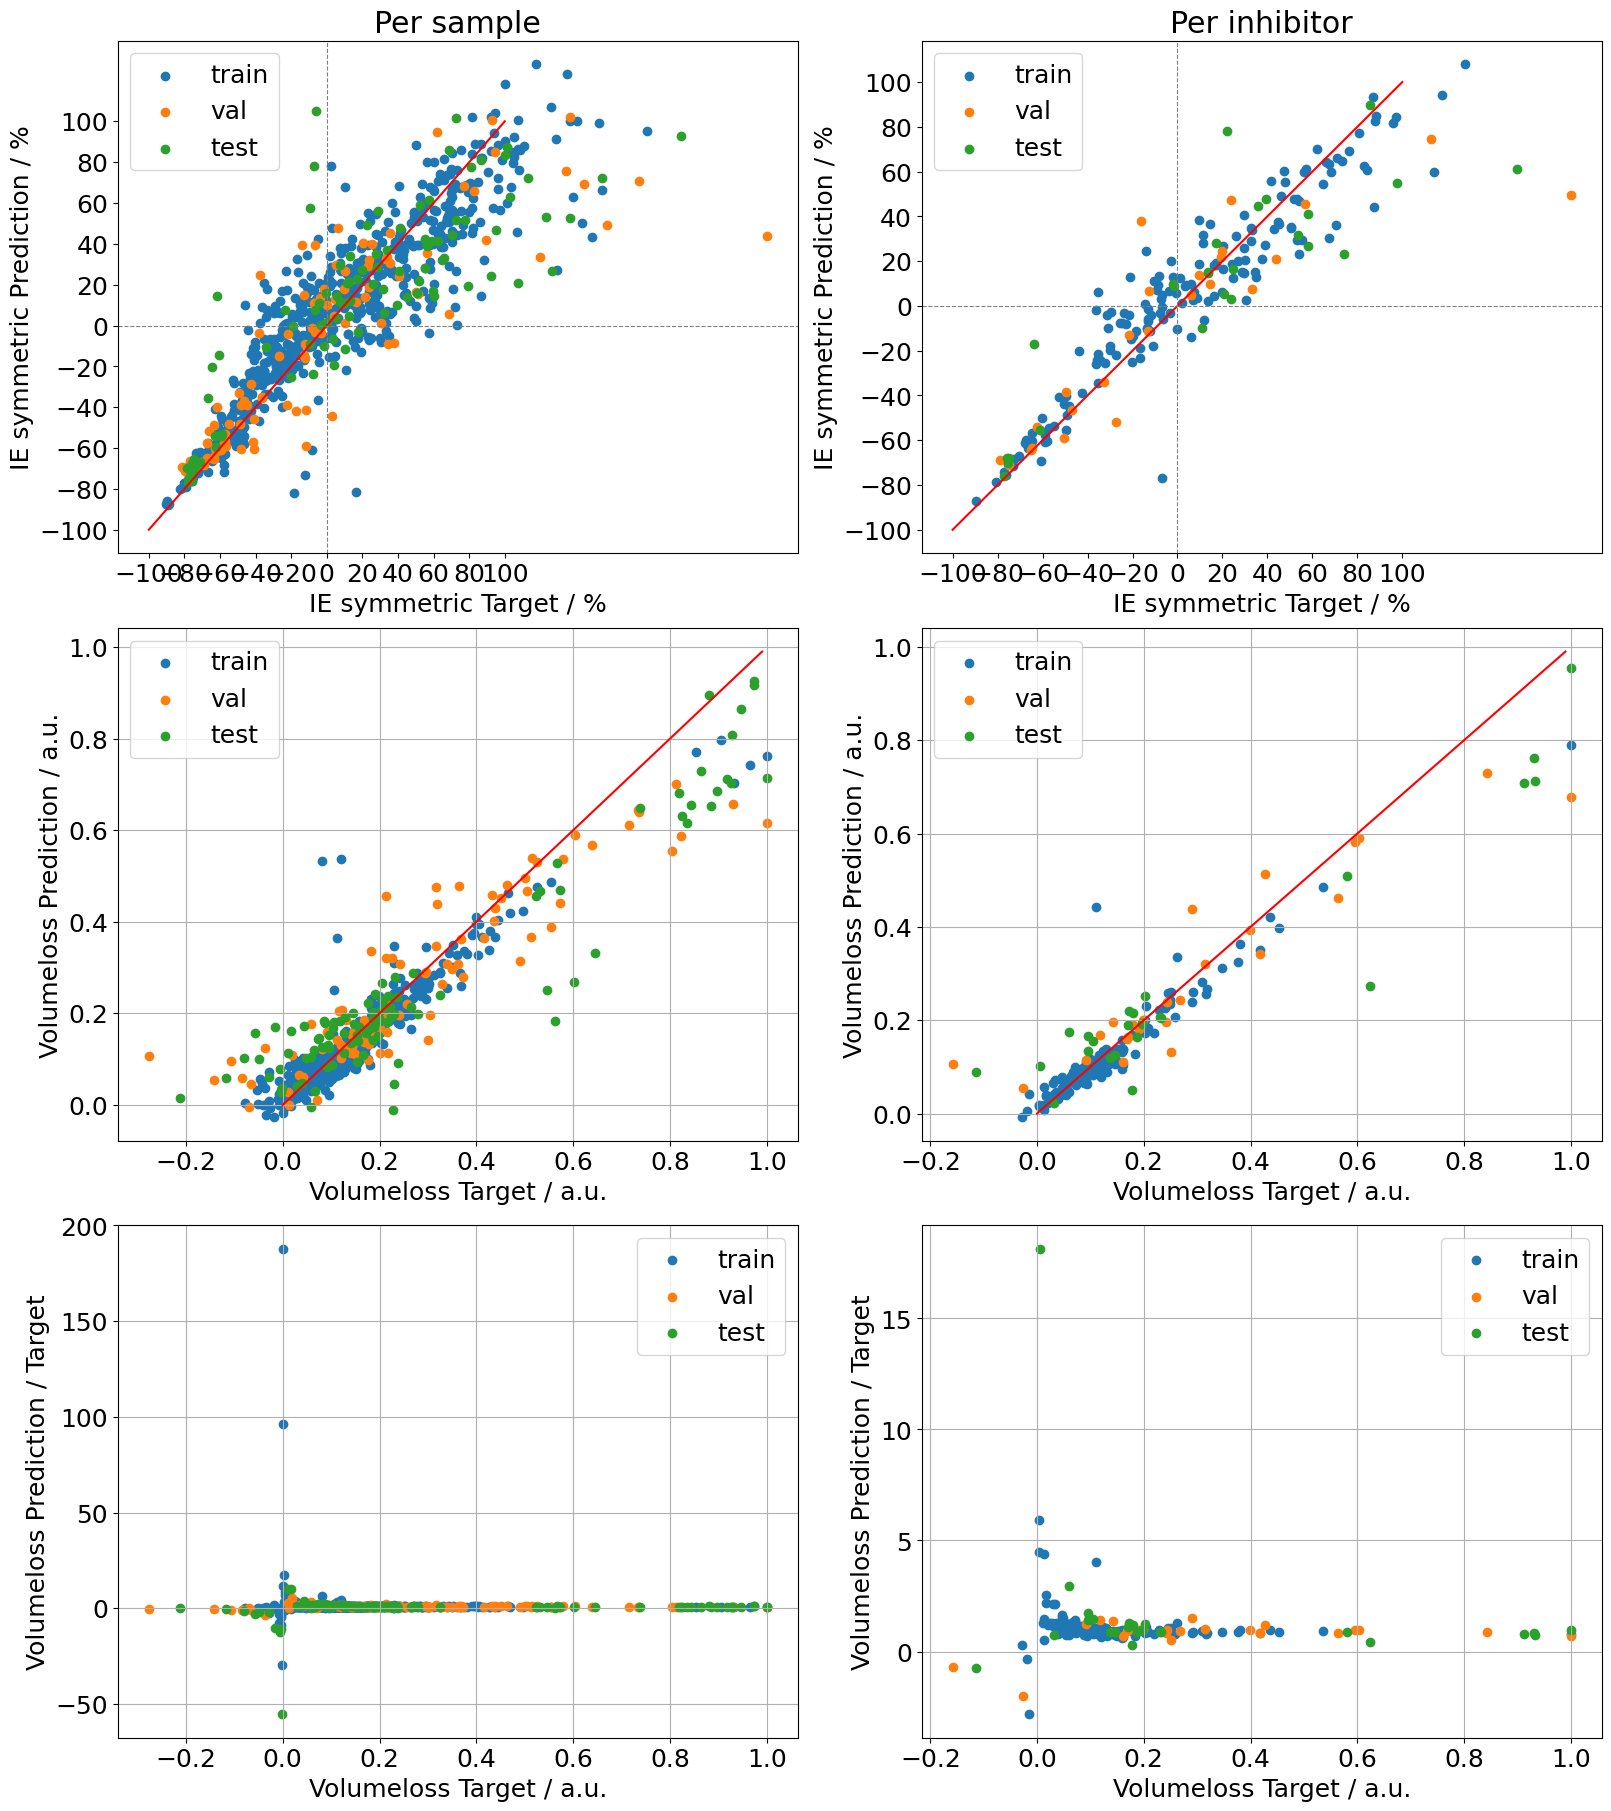

Model: model-dh1xlxcl, Average Sample Deviation: 17.06%, Median Sample Deviation: 10.63%, Min Sample Deviation: 0.05%, Max Sample Deviation: 203.67%
Model: model-dh1xlxcl, Average Inhibitor Deviation: 13.13%, Median Inhibitor Deviation: 8.30%, Min Inhibitor Deviation: 0.04%, Max Inhibitor Deviation: 125.59%


In [70]:
## MSE loss model
model = "model-dh1xlxcl"
# save_side_by_side(model, "test")
# save_side_by_side(model, "val")
# save_side_by_side(model, "train")
data_types = ["train", "val", "test"]
results, inhibitor = create_result_df(model, data_types)

fig, ax = plt.subplots(3, 2, figsize=(16, 18), constrained_layout=True)

ax[0][0].set_title("Per sample")
ax[0][1].set_title("Per inhibitor")

plot_ie_symmetric(ax[0][0], results)
plot_ie_symmetric(ax[0][1], inhibitor)

plot_target_vs_prediction(ax[1][0], results)
plot_target_vs_prediction(ax[1][1], inhibitor)

plot_normalized_target_vs_prediction(ax[2][0], results)
plot_normalized_target_vs_prediction(ax[2][1], inhibitor)

plt.show()

sample_score = calc_model_deviation(results)
inhibitor_score = calc_model_deviation(inhibitor)
print(f"Model: {model}, Average Sample Deviation: {sample_score[0]:.2f}%, Median Sample Deviation: {sample_score[1]:.2f}%, Min Sample Deviation: {sample_score[2]:.2f}%, Max Sample Deviation: {sample_score[3]:.2f}%")
print(f"Model: {model}, Average Inhibitor Deviation: {inhibitor_score[0]:.2f}%, Median Inhibitor Deviation: {inhibitor_score[1]:.2f}%, Min Inhibitor Deviation: {inhibitor_score[2]:.2f}%, Max Inhibitor Deviation: {inhibitor_score[3]:.2f}%")

# determine_systematic_bias(results, inhibitor)

## MAE Loss model with loss calculated only from negative values (Ci)

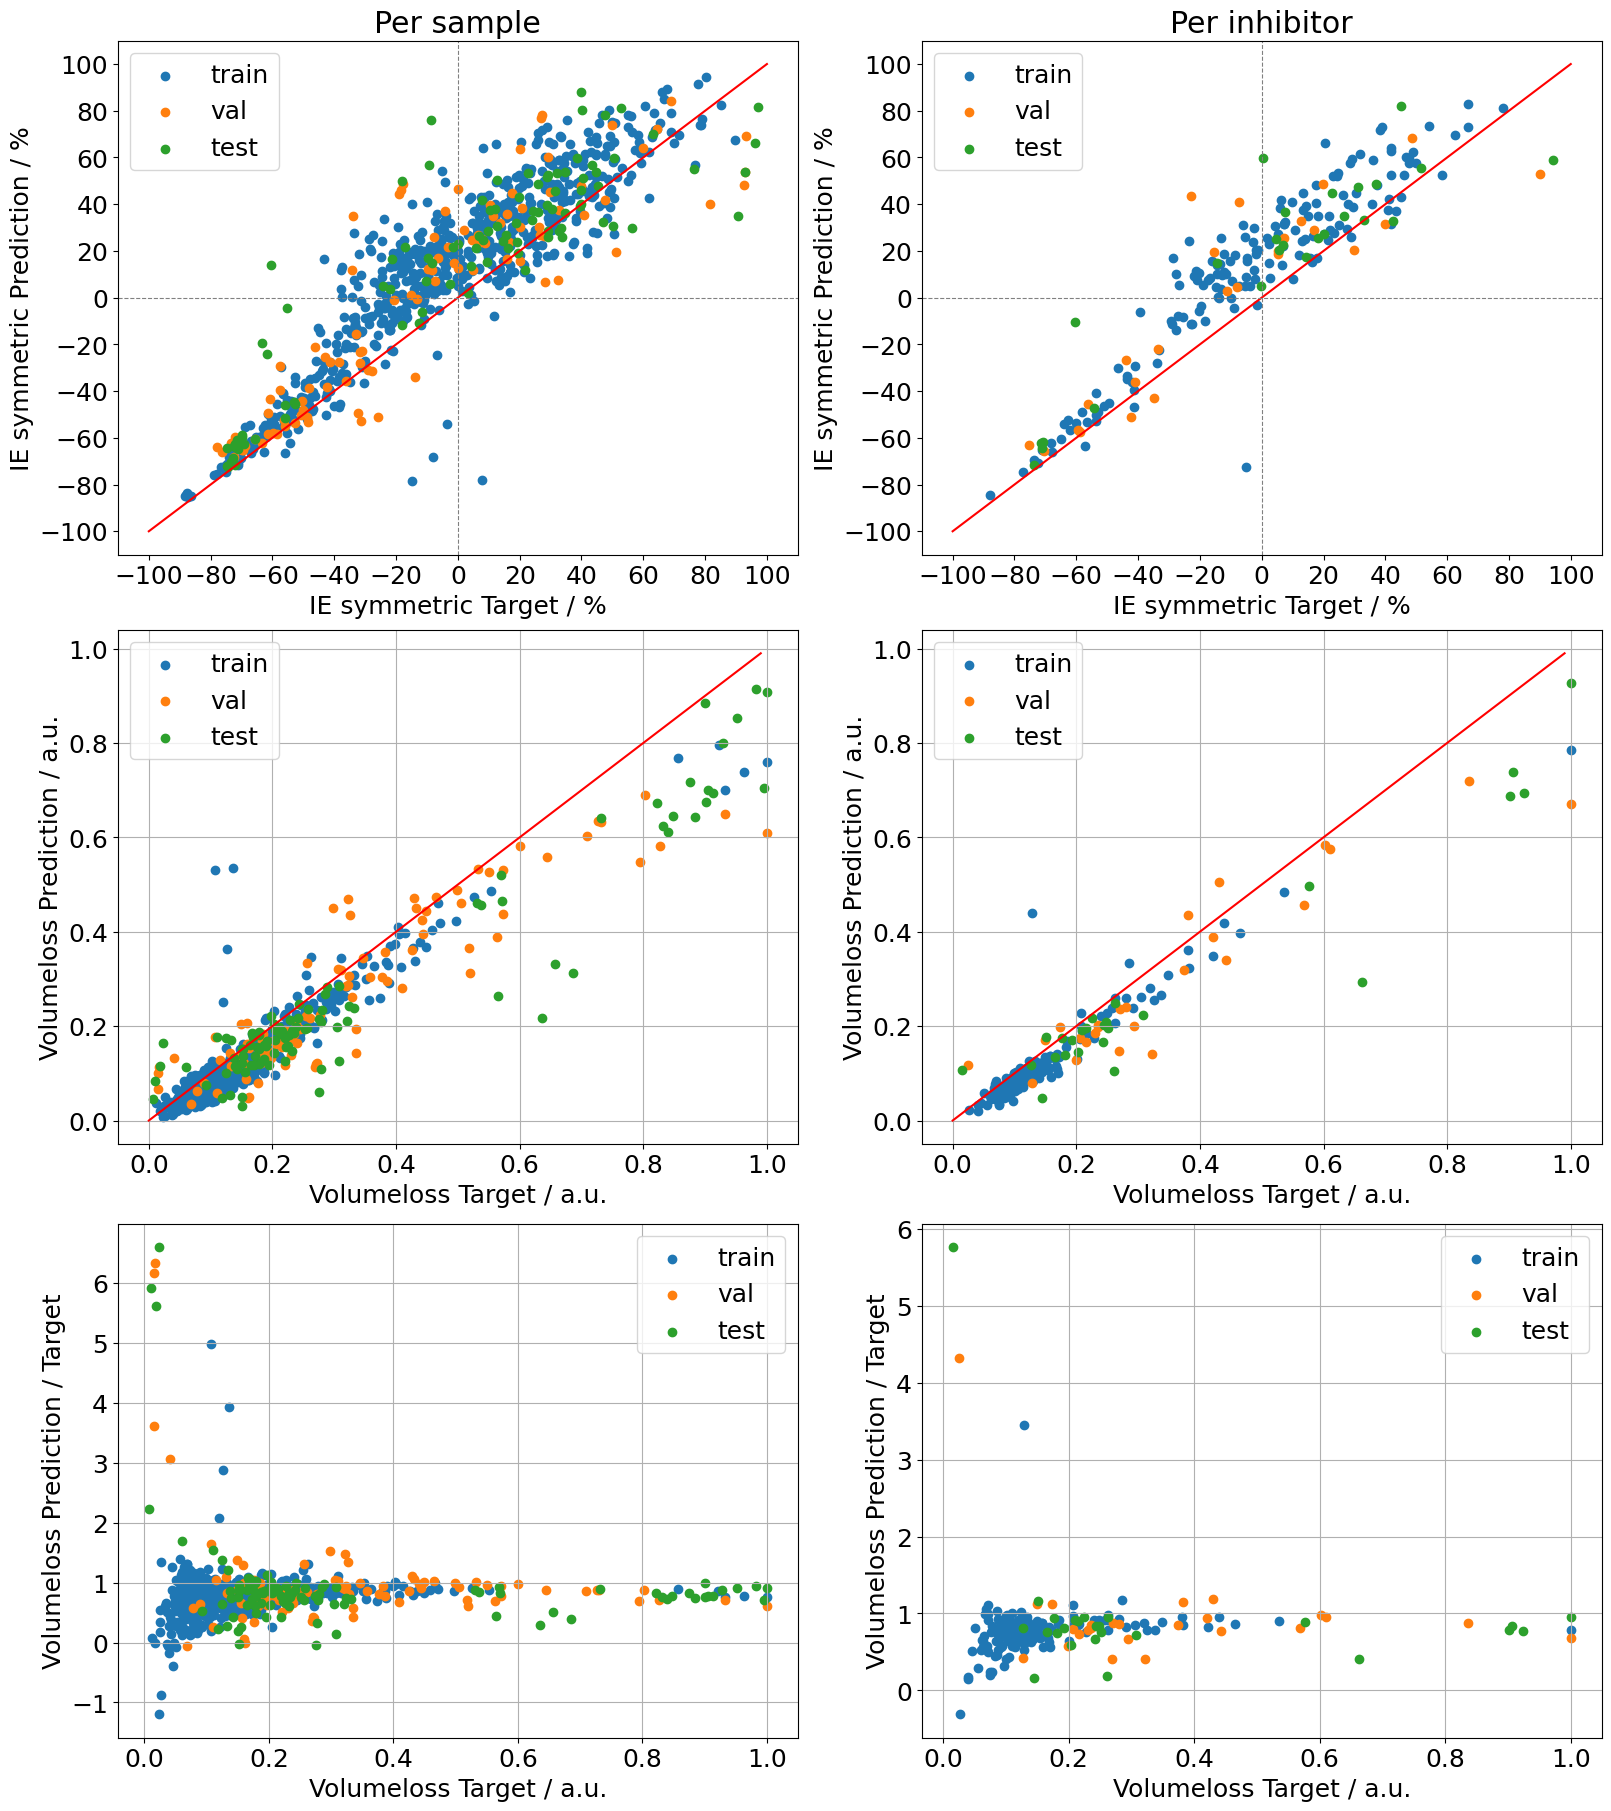

Model: model-dh1xlxcl, Average Sample Deviation: 17.51%, Median Sample Deviation: 14.39%, Min Sample Deviation: 0.03%, Max Sample Deviation: 85.92%
Model: model-dh1xlxcl, Average Inhibitor Deviation: 16.71%, Median Inhibitor Deviation: 13.46%, Min Inhibitor Deviation: 0.10%, Max Inhibitor Deviation: 67.12%


In [47]:
## MSE loss model
model = "model-dh1xlxcl"
# save_side_by_side(model, "test")
# save_side_by_side(model, "val")
# save_side_by_side(model, "train")
data_types = ["train", "val", "test"]
results, inhibitor = create_result_df(model, data_types)

fig, ax = plt.subplots(3, 2, figsize=(16, 18), constrained_layout=True)

ax[0][0].set_title("Per sample")
ax[0][1].set_title("Per inhibitor")

plot_ie_symmetric(ax[0][0], results, lower=True)
plot_ie_symmetric(ax[0][1], inhibitor, lower=True)

plot_target_vs_prediction(ax[1][0], results, lower=True)
plot_target_vs_prediction(ax[1][1], inhibitor, lower=True)

plot_normalized_target_vs_prediction(ax[2][0], results, lower=True)
plot_normalized_target_vs_prediction(ax[2][1], inhibitor, lower=True)

plt.show()

sample_score = calc_model_deviation(results, lower=True)
inhibitor_score = calc_model_deviation(inhibitor, lower=True)
print(f"Model: {model}, Average Sample Deviation: {sample_score[0]:.2f}%, Median Sample Deviation: {sample_score[1]:.2f}%, Min Sample Deviation: {sample_score[2]:.2f}%, Max Sample Deviation: {sample_score[3]:.2f}%")
print(f"Model: {model}, Average Inhibitor Deviation: {inhibitor_score[0]:.2f}%, Median Inhibitor Deviation: {inhibitor_score[1]:.2f}%, Min Inhibitor Deviation: {inhibitor_score[2]:.2f}%, Max Inhibitor Deviation: {inhibitor_score[3]:.2f}%")

# determine_systematic_bias(results, inhibitor)

### Target vs predicted distributions

/tmp/ipykernel_381677/4089664277.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


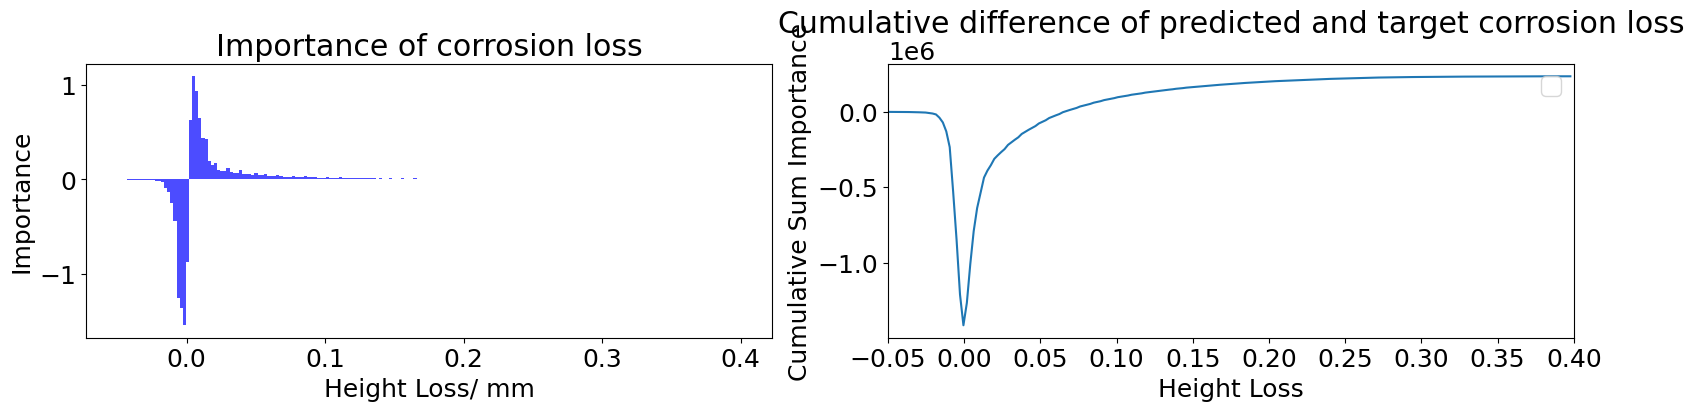

In [53]:
nbins = 200
binedges = np.linspace(-0.05, 0.4, nbins+1, endpoint=True)
hist = np.zeros(nbins, dtype=float)

target_sum = 0.0
pred_sum = 0.0

target_image_dataset = DataTypeImageDataset(["train", "val", "test"])
pred_image_dataset = iter(DataTypeImageDataset(["train", "val", "test"], model=model))

for target_image in target_image_dataset:
    pred_image = next(pred_image_dataset)
    difference_image = target_image - pred_image

    target_image_sum = np.sum(target_image)
    target_sum += target_image_sum
    pred_image_sum = np.sum(pred_image)
    pred_sum += pred_image_sum

    # compute bin indices for each pixel
    bin_idx = np.digitize(target_image.ravel(), binedges) - 1

    # keep valid bins
    valid = (bin_idx >= 0) & (bin_idx < nbins)

    # accumulate weighted histogram
    temp_hist = np.bincount(
        bin_idx[valid],
        weights=difference_image.ravel()[valid],
        minlength=nbins
    )
    hist += temp_hist

fig, ax = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)

ax[0].bar(binedges[:-1], hist / hist.sum(), width=np.diff(binedges), color='blue', alpha=0.7, align='edge')
ax[0].set_xlabel("Height Loss/ mm")
ax[0].set_ylabel("Importance")
ax[0].set_title("Importance of corrosion loss")

# Add cdf of the second plot
cdf = np.cumsum(hist)
ax[1].plot(binedges[:-1], cdf)
ax[1].set_xlabel("Height Loss")
ax[1].set_ylabel("Cumulative Sum Importance")
ax[1].set_title("Cumulative difference of predicted and target corrosion loss")
ax[1].set_xlim(-0.05, 0.4)
ax[1].legend()

plt.show()

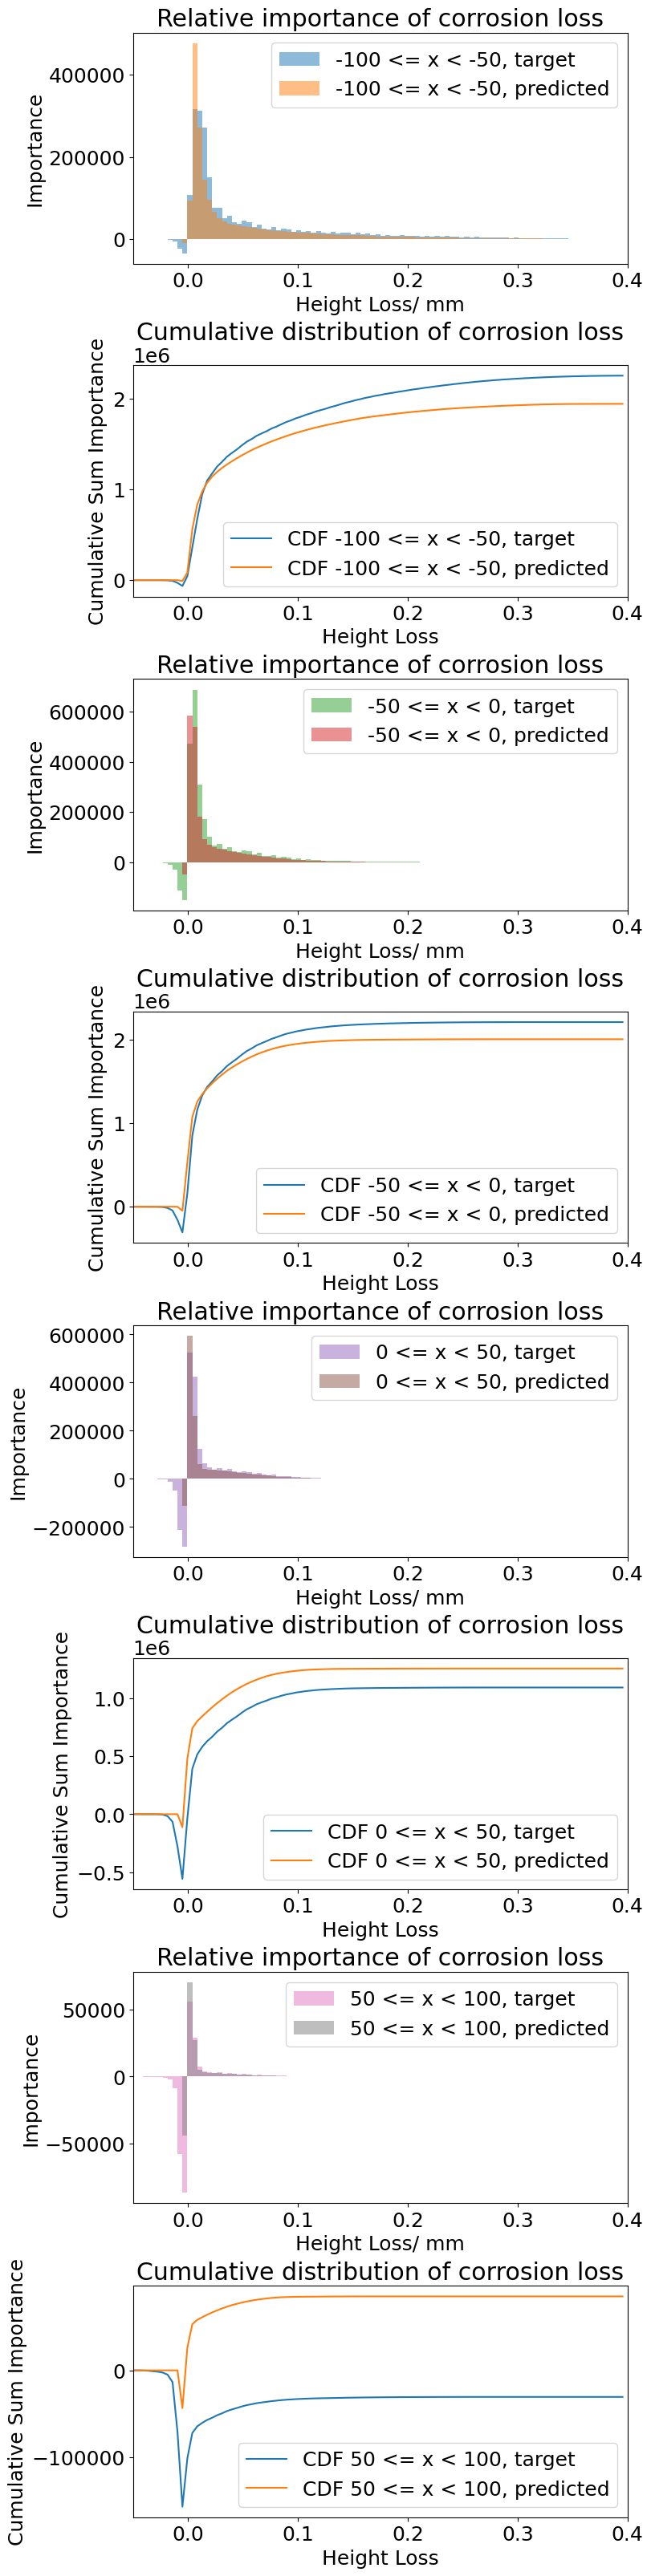

In [50]:
# Weighted histogram of categorized by IE symmetric lower
inhibitor_df["ie_symmetric_lower"] = inhibitor_df.lower_volumeloss.apply(calc_ie_symmetric_lower)
ie_range = np.arange(-100, 101, 50)
ranges = zip(ie_range[:-1], ie_range[1:])
fig, ax = plt.subplots((len(ie_range)-1) * 2, 1, figsize=(8, ((len(ie_range)-1) * 2)*4), constrained_layout=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = itertools.cycle(colors)

i = 0
for x_min, x_max in ranges:
    subset = inhibitor_df[(inhibitor_df.ie_symmetric_lower >= x_min) & (inhibitor_df.ie_symmetric_lower < x_max)]
    image_dataset = IdsImageDataset(subset.id.values, return_mask=True)
    # Get images
    values = []
    for image, mask in image_dataset:
        values.extend(image[~mask].ravel())
    values = np.array(values)

    hist, bins, _ = ax[2*i].hist(values, bins=100, range=(-0.05, 0.4), weights=values, alpha=0.5, label=f"{x_min} <= x < {x_max}, target", color=next(color_cycle))

    # Add cdf of the second plot
    cdf = np.cumsum(hist)
    ax[2*i+1].plot(bins[:-1], cdf, label=f"CDF {x_min} <= x < {x_max}, target")


    image_dataset = IdsImageDataset(subset.id.values, model=model, return_mask=True)
    # Get images
    values = []
    for image, mask in image_dataset:
        values.extend(image[~mask].ravel())
    values = np.array(values)

    hist, bins, _ = ax[2*i].hist(values, bins=100, range=(-0.05, 0.4), weights=values, alpha=0.5, label=f"{x_min} <= x < {x_max}, predicted", color=next(color_cycle))


    ax[2*i].set_xlabel("Height Loss/ mm")
    ax[2*i].set_ylabel("Importance")
    ax[2*i].set_title("Importance of corrosion loss")
    ax[2*i].set_xlim(-0.05, 0.4)
    ax[2*i].legend()

    # Add cdf of the second plot
    cdf = np.cumsum(hist)
    ax[2*i+1].plot(bins[:-1], cdf, label=f"CDF {x_min} <= x < {x_max}, predicted")
    ax[2*i+1].set_xlabel("Height Loss")
    ax[2*i+1].set_ylabel("Cumulative Sum Importance")
    ax[2*i+1].set_title("Cumulative distribution of corrosion loss")
    ax[2*i+1].set_xlim(-0.05, 0.4)
    ax[2*i+1].legend()

    i += 1


plt.show()



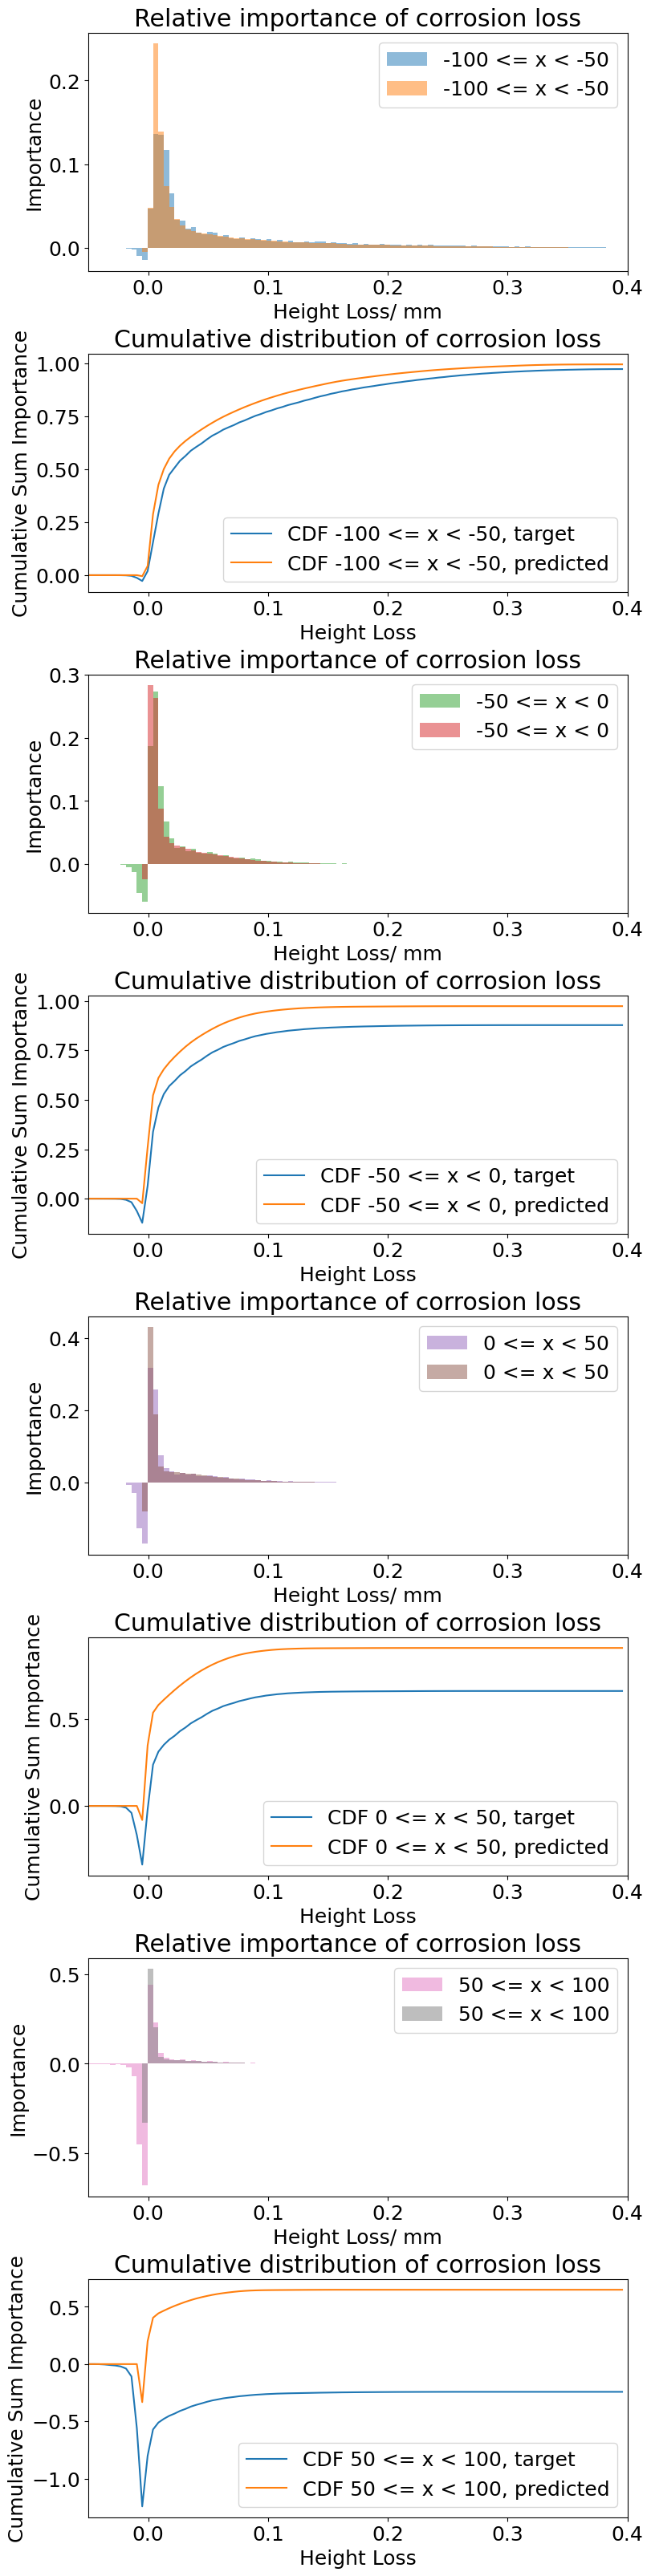

In [ ]:
# Weighted histogram of categorized by IE symmetric lower
inhibitor_df["ie_symmetric_lower"] = inhibitor_df.lower_volumeloss.apply(calc_ie_symmetric_lower)
ie_range = np.arange(-100, 101, 50)
ranges = zip(ie_range[:-1], ie_range[1:])
fig, ax = plt.subplots((len(ie_range)-1) * 2, 1, figsize=(8, ((len(ie_range)-1) * 2)*4), constrained_layout=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = itertools.cycle(colors)

i = 0
for x_min, x_max in ranges:
    subset = inhibitor_df[(inhibitor_df.ie_symmetric_lower >= x_min) & (inhibitor_df.ie_symmetric_lower < x_max)]
    image_dataset = IdsImageDataset(subset.id.values, return_mask=True)
    # Get images
    values = []
    for image, mask in image_dataset:
        values.extend(image[~mask].ravel())
    values = np.array(values)

    # hist, bins, _ = ax[0].hist(values, bins=100, range=(min_val, max_val), weights=values / values[values > 0].sum(), alpha=0.5, label=f"{x_min} <= x < {x_max}")
    hist, bins, _ = ax[2*i].hist(values, bins=100, range=(-0.05, 0.4), weights=values / values[values > 0].sum(), alpha=0.5, label=f"{x_min} <= x < {x_max}, target", color=next(color_cycle))

    # Add cdf of the second plot
    cdf = np.cumsum(hist)
    ax[2*i+1].plot(bins[:-1], cdf, label=f"CDF {x_min} <= x < {x_max}, target")


    image_dataset = IdsImageDataset(subset.id.values, model=model, return_mask=True)
    # Get images
    values = []
    for image, mask in image_dataset:
        values.extend(image[~mask].ravel())
    values = np.array(values)

    # hist, bins, _ = ax[0].hist(values, bins=100, range=(min_val, max_val), weights=values / values[values > 0].sum(), alpha=0.5, label=f"{x_min} <= x < {x_max}")
    hist, bins, _ = ax[2*i].hist(values, bins=100, range=(-0.05, 0.4), weights=values / values[values > 0].sum(), alpha=0.5, label=f"{x_min} <= x < {x_max}, predicted", color=next(color_cycle))


    ax[2*i].set_xlabel("Height Loss/ mm")
    ax[2*i].set_ylabel("Importance")
    ax[2*i].set_title("Relative importance of corrosion loss")
    ax[2*i].set_xlim(-0.05, 0.4)
    ax[2*i].legend()

    # Add cdf of the second plot
    cdf = np.cumsum(hist)
    ax[2*i+1].plot(bins[:-1], cdf, label=f"CDF {x_min} <= x < {x_max}, predicted")
    ax[2*i+1].set_xlabel("Height Loss")
    ax[2*i+1].set_ylabel("Cumulative Sum Importance")
    ax[2*i+1].set_title("Cumulative distribution of corrosion loss")
    ax[2*i+1].set_xlim(-0.05, 0.4)
    ax[2*i+1].legend()

    i += 1


plt.show()

